## Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[0] / "scripts"))

import prepare as prepare
import services as services
import roi as roi_services
import bss_pipeline as bss_pl
import visualization as vis

from scipy.interpolate import make_interp_spline

%load_ext autoreload
%autoreload 2

### fixed variables

In [2]:
N_PC = 10 # discovered by analysis
NFRAMES_OUT = 800
SCALE_OUT = 0.2
FPS_OUT = 240
N_PEAKS = 5

VIDEO_PATH_IN = str(Path.cwd().parents[0] / "videos/2_camp/20260520/20260520_1/m/VID_20260520_072412821.mp4")
VIDEO_NAME = VIDEO_PATH_IN.split("/")[-1]
VIDEO_PATH_OUT = str(Path.cwd().parents[0] / "outputs" / VIDEO_NAME)

ROIS = roi_services.load_rois(str(Path.cwd().parents[0] / "rois/rois.json"))
VIDEO_ROI = ROIS[VIDEO_NAME]

video_in_info = services.get_video_info(VIDEO_PATH_IN)
video_in_info

{'path': '/home/reginaldo/workspaces/PythonLanguage/marajo/videos/2_camp/20260520/20260520_1/m/VID_20260520_072412821.mp4',
 'fps': 29.923232187827843,
 'width': 1080,
 'height': 1920,
 'frames': 2639,
 'duration': 88.19,
 'shape': (1920, 1080, 3)}

### pre-processing

In [3]:
# prepare.pre_processing(VIDEO_PATH_IN, VIDEO_PATH_OUT, NFRAMES_OUT, FPS_OUT, SCALE_OUT, VIDEO_ROI)
video_out_info = services.get_video_info(VIDEO_PATH_OUT)
video_out_info

{'path': '/home/reginaldo/workspaces/PythonLanguage/marajo/outputs/VID_20260520_072412821.mp4',
 'fps': 240.0,
 'width': 202,
 'height': 150,
 'frames': 800,
 'duration': 3.33,
 'shape': (150, 202, 3)}

### computer vision

In [4]:
unmixed, winvmix, w = bss_pl.run_pipeline(VIDEO_PATH_OUT, N_PC)

In [5]:
fft_data = bss_pl.compute_fft_for_components(unmixed, video_out_info["fps"], range(N_PC))
peaks_info = bss_pl.get_highest_peak_frequencies(fft_data, N_PEAKS)

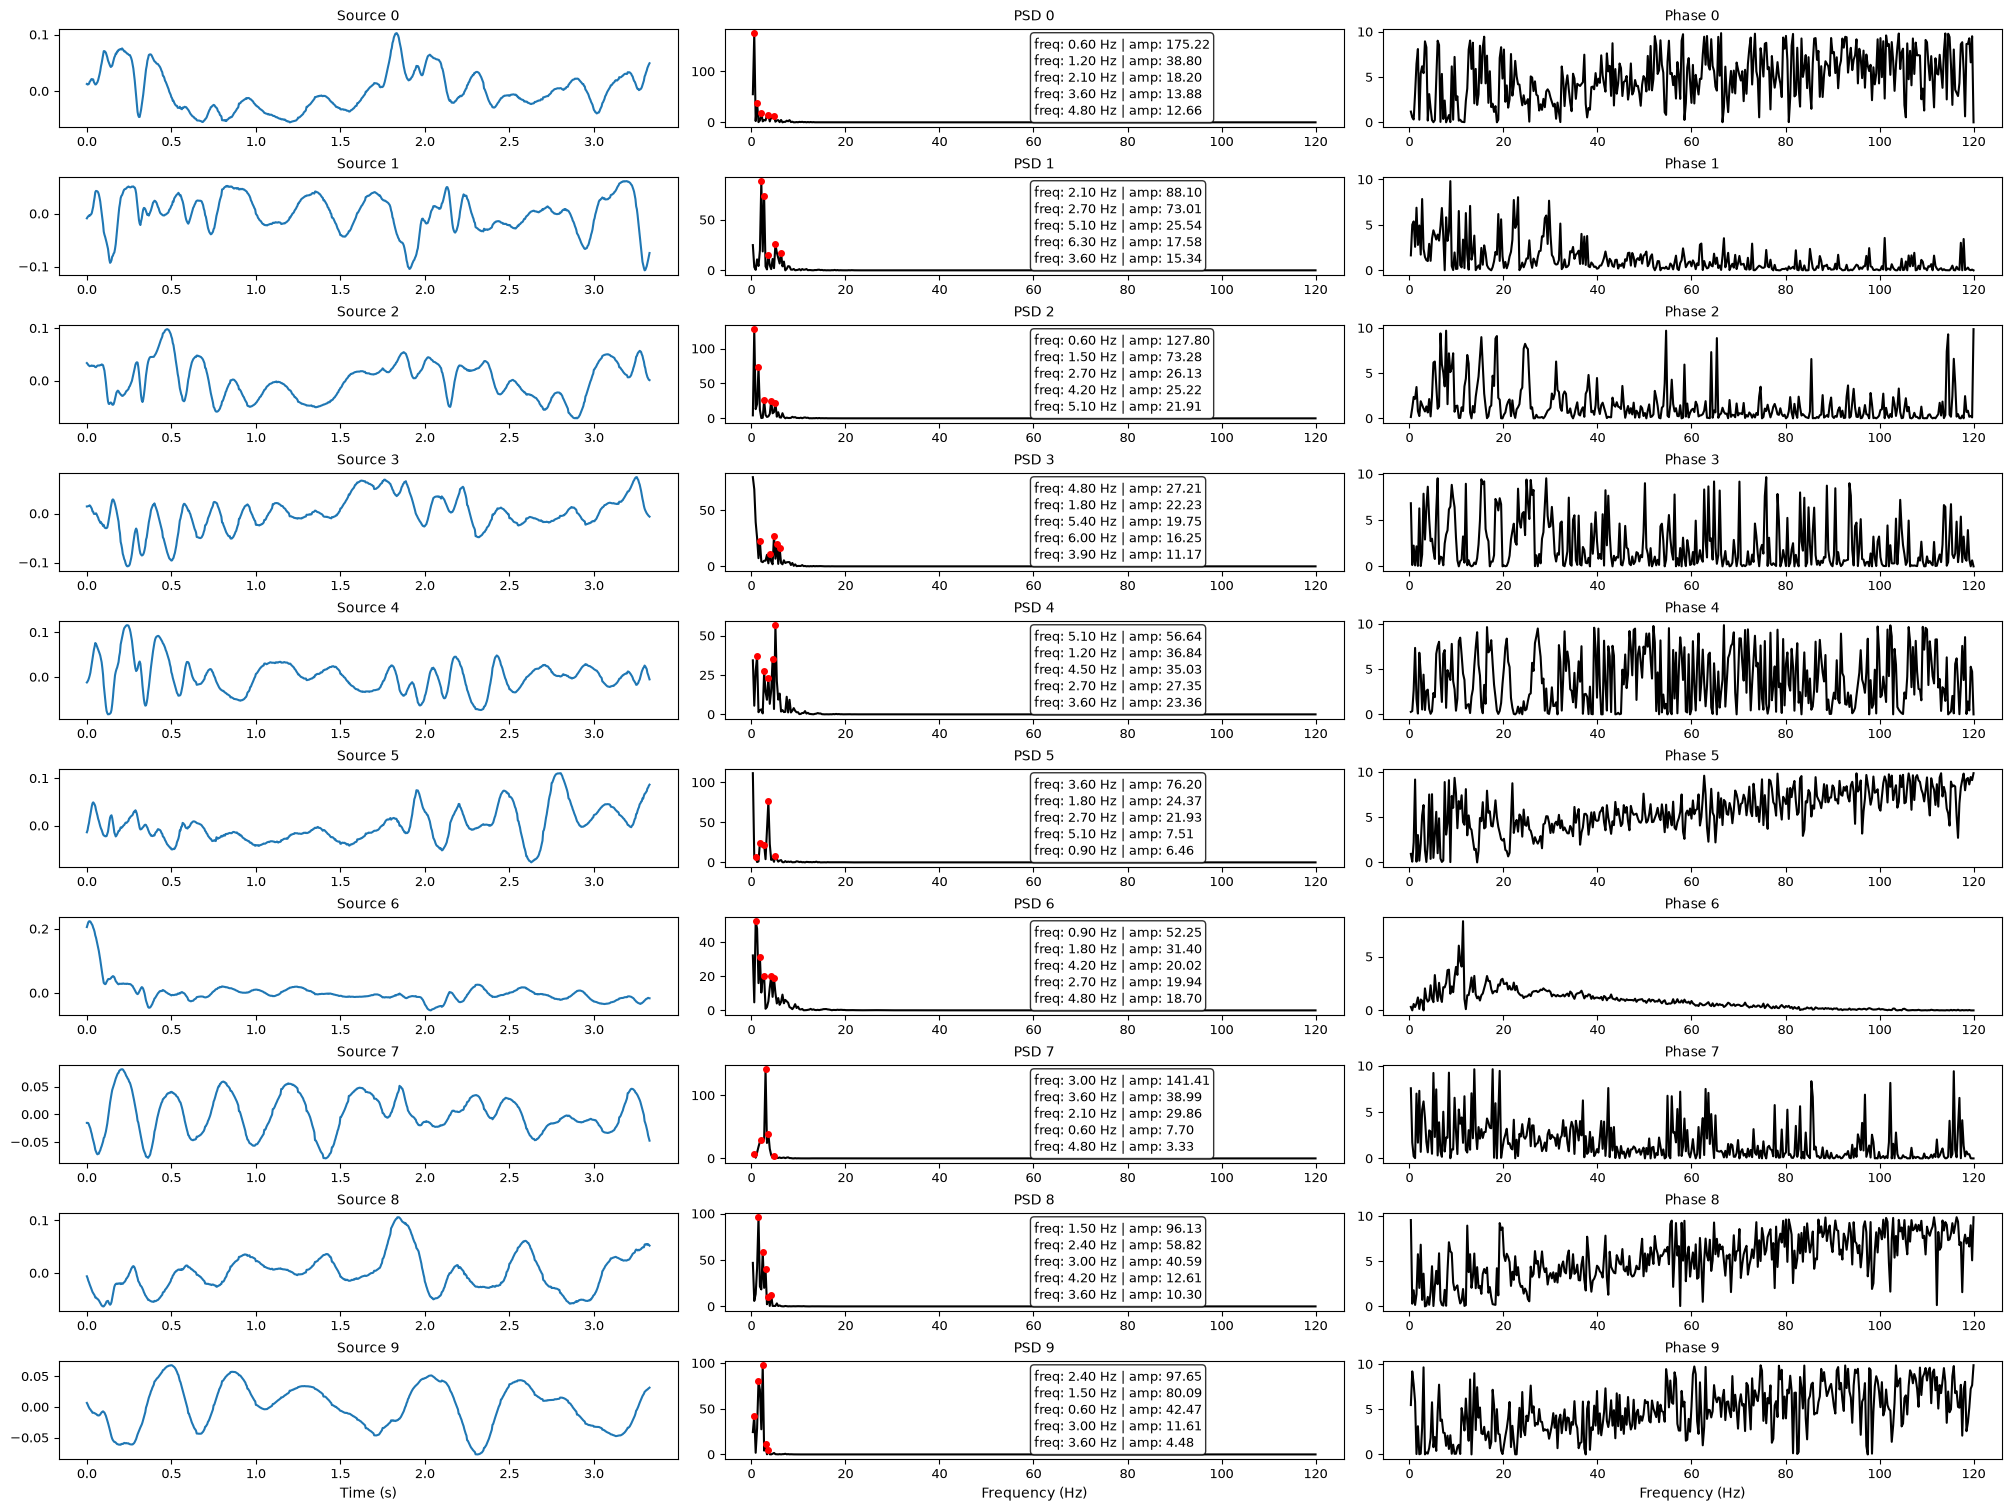

In [6]:
vis.plot_source_psd_phase(fft_data, peaks_info, video_out_info, range(N_PC))

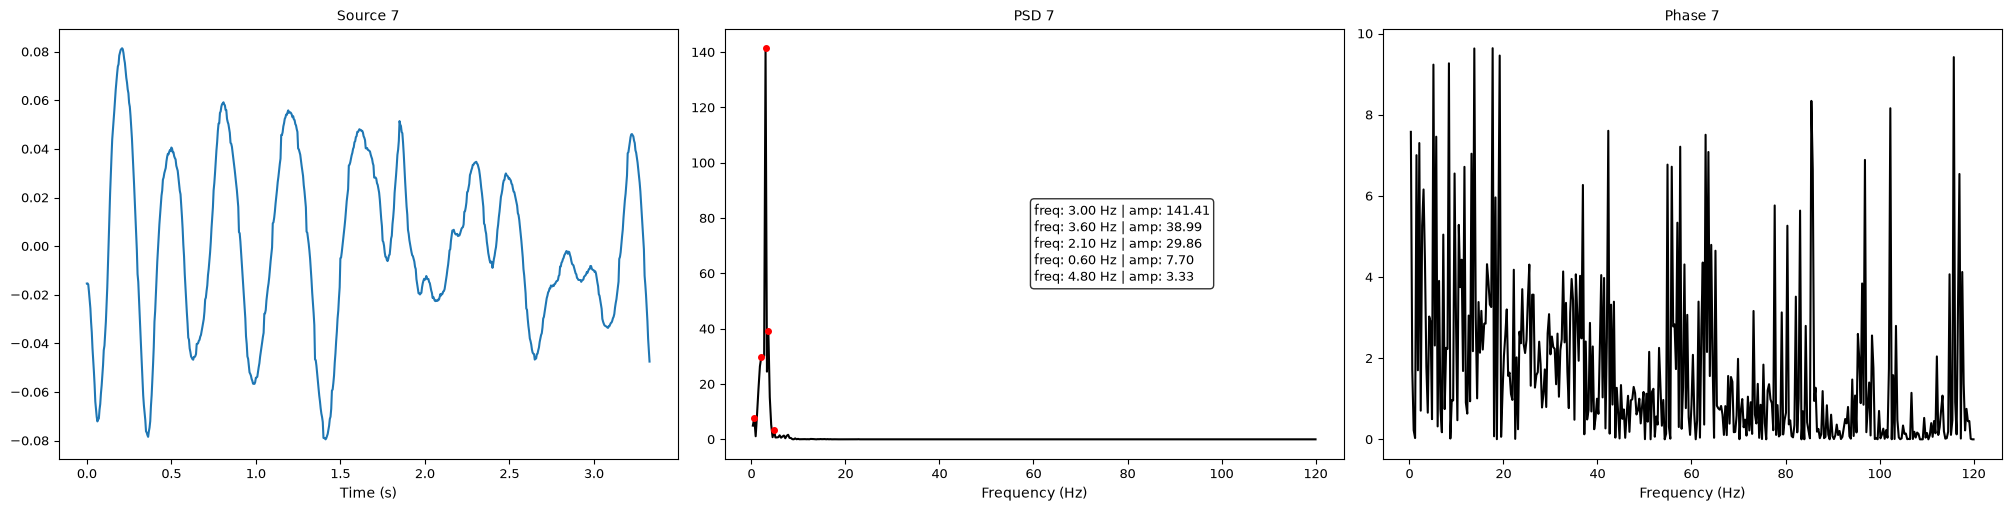

In [7]:
vis.plot_source_psd_phase(fft_data, peaks_info, video_out_info, [7], 20, 5)

In [8]:
mode_shapes = bss_pl.compute_mode_shapes(winvmix, w, N_PC, range(N_PC))

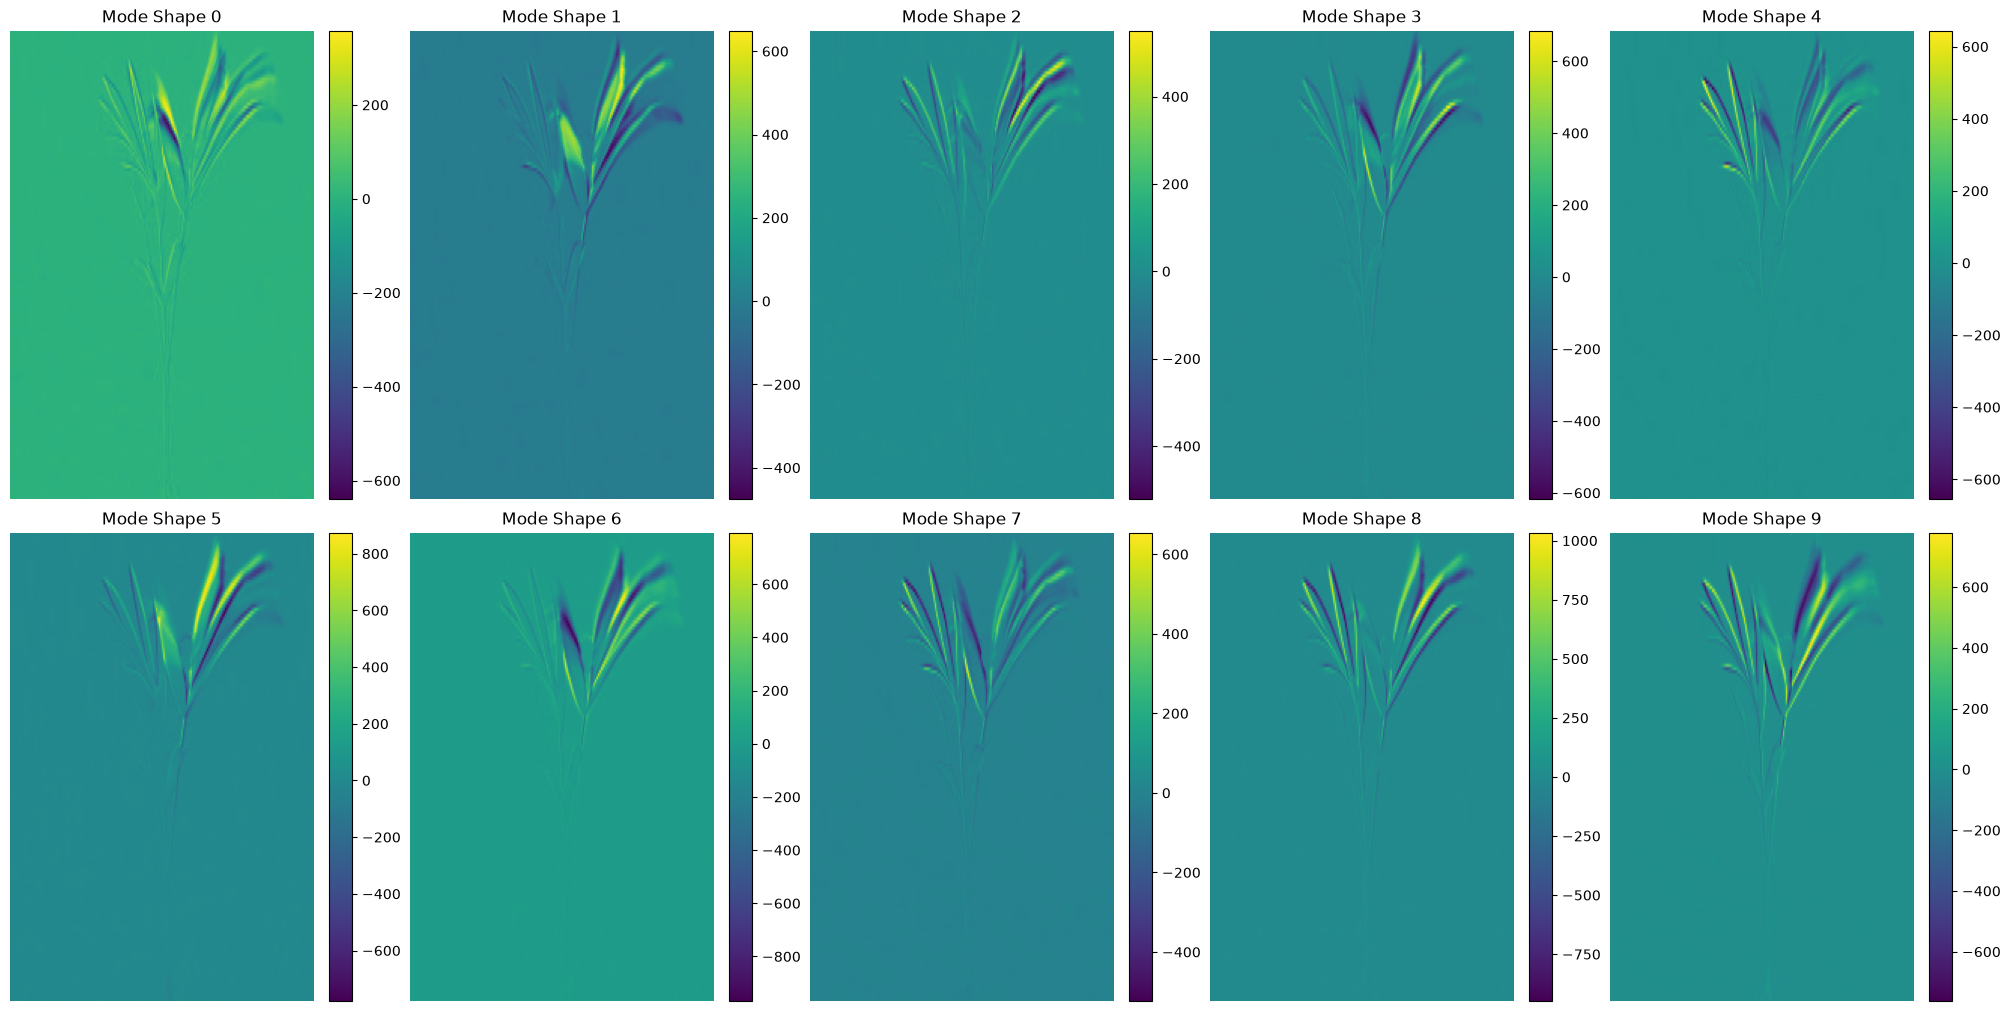

In [9]:
vis.plot_mode_shapes(mode_shapes, video_out_info['height'], video_out_info['width'], range(N_PC), save = True)